In [1]:
import importlib
import sys
import numpy as np
from collections import Counter
import pandas as pd

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')

In [2]:
import event_log_loader.new_event_log_loader_v2
importlib.reload(event_log_loader.new_event_log_loader_v2)
from event_log_loader.new_event_log_loader_v2 import PrefixesDataFrameLoader, EventLogLoader

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(17)

event_log_location = '../../../../../../data/data/Sepsis.csv'

result_name = 'sepsis_all'

# dynamic categorical attributes
cat_dynamic = ['concept:name', 'org:group', 'lifecycle:transition']

# static categorical attributes
cat_static = ['Age',
              #
              'InfectionSuspected',
              #
              'Diagnose',
              'DiagnosticLacticAcid',
              'DiagnosticBlood',
              'DiagnosticArtAstrup',
              'DiagnosticIC',
              'DiagnosticSputum',
              'DiagnosticLiquor',
              'DiagnosticOther',
              'DiagnosticUrinarySediment',
              'DiagnosticECG',
              'DiagnosticUrinaryCulture',
              'DiagnosticXthorax',
              #
              'SIRSCritTachypnea',
              'SIRSCritHeartRate',
              'SIRSCriteria2OrMore',
              'SIRSCritTemperature',
              'SIRSCritLeucos',
              # 
              'Hypotensie',
              'Oligurie',          
              'Infusion',
              'Hypoxie',
              'DisfuncOrg',
              ]

# dynamic numerical attributes
num_dynamic = ['case_elapsed_time',
               'event_elapsed_time',
               'day_in_week',
               'seconds_in_day',
               'Leucocytes',
               'CRP',
               'LacticAcid']
num_dyn_log = []

# static numeric attributes
num_static = []

min_suffix_size = 5

# 15% test size:
test_validation_size = 0.15

event_log_properties = {# case id
                        'case_name' : 'case:concept:name',
                        # activity
                        'concept_name' : 'concept:name',
                        # time values and computaitons
                        'timestamp_name' : 'time:timestamp',
                        'time_since_case_start_column' : 'case_elapsed_time',
                        'time_since_last_event_column' : 'event_elapsed_time',
                        'day_in_week_column' : 'day_in_week',
                        'seconds_in_day_column' : 'seconds_in_day',
                        # min suffix size for eos padding right
                        'min_suffix_size' : min_suffix_size,
                        # trian and test split
                        # train and test split
                        # 'train_validation_size' : 0.15
                        'train_validation_size' : test_validation_size / (1-test_validation_size), # ensures that val used as cal set has same size as test set
                        'test_validation_size' :test_validation_size,
                        # window size for padding
                        'window_size' : 'auto',
                        # dynamic and static values
                        'categorical_columns' : cat_dynamic,
                        'static_categorical_columns' : cat_static,
                        'continuous_columns' : num_dynamic,
                        'continuous_positive_columns' : num_dyn_log,
                        'static_continuous_columns' : num_static}


## Create dataframes of prefixes

In [3]:
# object to create datframe of prefixes for petri-net repaly marking computation
pref_adopt_dataframe = PrefixesDataFrameLoader(event_log_location=event_log_location, event_log_properties=event_log_properties)

In [4]:
# output if necessary the raw dataframe: dynamic are lists, static values
raw_data = pref_adopt_dataframe.get_raw_dataframe()
raw_data

,case:concept:name,concept:name,org:group,lifecycle:transition,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,Leucocytes,CRP,...,SIRSCritTachypnea,SIRSCritHeartRate,SIRSCriteria2OrMore,SIRSCritTemperature,SIRSCritLeucos,Hypotensie,Oligurie,Infusion,Hypoxie,DisfuncOrg
0,A,"[ER Registration, Leucocytes, CRP, LacticAcid,...","[A, B, B, B, C, A, A, A, D, B, B, B, B, B, B, ...","[complete, complete, complete, complete, compl...","[0.0, 679.0, 679.0, 679.0, 1076.0, 1099.0, 100...","[nan, 679.0, 679.0, 679.0, 397.0, 23.0, 8987.0...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 6, 6, 1, 1, ...","[40541, 41220, 41220, 41220, 41617, 41640, 506...","[nan, 9.6, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, 21.0, nan, nan, nan, nan, nan, nan,...",...,True,True,True,True,False,True,False,True,False,True
1,AA,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B, A, A]","[complete, complete, complete, complete, compl...","[0.0, 41.0, 51.0, 1516.0, 1516.0, 1516.0, 1927...","[nan, 41.0, 10.0, 1465.0, 1465.0, 1465.0, 1775...","[2, 2, 2, 2, 2, 2, 2, 2]","[32804, 32845, 32855, 34320, 34320, 34320, 520...","[nan, nan, nan, 8.6, nan, nan, nan, nan]","[nan, nan, nan, nan, nan, 23.0, nan, nan]",...,True,True,True,True,False,False,False,True,False,False
2,AAA,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, A, B, B, B, A, I, E, ?]","[complete, complete, complete, complete, compl...","[0.0, 148.0, 168.0, 197.0, 1599.0, 1599.0, 159...","[nan, 148.0, 20.0, 29.0, 1402.0, 1402.0, 1402....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 5, 4]","[11781, 11929, 11949, 11978, 13380, 13380, 133...","[nan, nan, nan, nan, 20.8, nan, nan, nan, nan,...","[nan, nan, nan, nan, nan, 68.0, nan, nan, nan,...",...,False,True,True,True,False,False,False,True,False,False
3,AB,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B, A, A]","[complete, complete, complete, complete, compl...","[0.0, 91.0, 105.0, 437.0, 437.0, 437.0, 14179....","[nan, 91.0, 14.0, 332.0, 332.0, 332.0, 13742.0...","[6, 6, 6, 6, 6, 6, 6, 6]","[35743, 35834, 35848, 36180, 36180, 36180, 499...","[nan, nan, nan, nan, nan, 15.7, nan, nan]","[nan, nan, nan, 48.0, nan, nan, nan, nan]",...,True,True,True,True,False,False,False,True,False,False
4,ABA,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, A, B, B, B, A, F, B, B, B, B, B, B, ...","[complete, complete, complete, complete, compl...","[0.0, 1237.0, 1255.0, 1287.0, 2856.0, 2856.0, ...","[nan, 1237.0, 18.0, 32.0, 1569.0, 1569.0, 1569...","[6, 6, 6, 6, 6, 6, 6, 6, 6, 0, 1, 1, 3, 3, 4, ...","[40944, 42181, 42199, 42231, 43800, 43800, 438...","[nan, nan, nan, nan, nan, 2.0, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, 78.0, nan, nan,...",...,False,True,True,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044,ZV,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B, A, A, I, B, B, E]","[complete, complete, complete, complete, compl...","[0.0, 158.0, 171.0, 1422.0, 1422.0, 1422.0, 82...","[nan, 158.0, 13.0, 1251.0, 1251.0, 1251.0, 680...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 6, 6, 1]","[52638, 52796, 52809, 54060, 54060, 54060, 608...","[nan, nan, nan, nan, 16.9, nan, nan, nan, nan,...","[nan, nan, nan, nan, nan, 61.0, nan, nan, nan,...",...,True,True,True,True,False,False,False,True,False,False
1045,ZW,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, A, B, B, B, A, F, F, B, B, E]","[complete, complete, complete, complete, compl...","[0.0, 105.0, 216.0, 291.0, 1501.0, 1501.0, 150...","[nan, 105.0, 111.0, 75.0, 1210.0, 1210.0, 1210...","[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 1]","[22079, 22184, 22295, 22370, 23580, 23580, 235...","[nan, nan, nan, nan, 13.0, nan, nan, nan, nan,...","[nan, nan, nan, nan, nan, nan, 76.0, nan, nan,...",...,False,True,True,True,False,False,False,True,False,False
1046,ZX,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B, A, A, I, E]","[complete, c

In [5]:
# outputs for perturbations:
# train_df, val_df, test_df = pref_adopt_dataframe.get_all_datasets()
# categories = pref_adopt_dataframe.extract_feature_info()

In [6]:
# prefix dataset for potential marking computation
train_pref_df = pref_adopt_dataframe.get_dataset('train')
train_pref_df

,case:concept:name,prefix_length,concept:name,org:group,lifecycle:transition,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,Leucocytes,...,SIRSCritTachypnea,SIRSCritHeartRate,SIRSCriteria2OrMore,SIRSCritTemperature,SIRSCritLeucos,Hypotensie,Oligurie,Infusion,Hypoxie,DisfuncOrg
0,A,1,[ER Registration],[A],[complete],[0.0],[nan],[2.0],[40541.0],[nan],...,True,True,True,True,False,True,False,True,False,True
1,A,2,"[ER Registration, Leucocytes]","[A, B]","[complete, complete]","[0.0, 679.0]","[nan, 679.0]","[2.0, 2.0]","[40541.0, 41220.0]","[nan, 9.600000381469727]",...,True,True,True,True,False,True,False,True,False,True
2,A,3,"[ER Registration, Leucocytes, CRP]","[A, B, B]","[complete, complete, complete]","[0.0, 679.0, 679.0]","[nan, 679.0, 679.0]","[2.0, 2.0, 2.0]","[40541.0, 41220.0, 41220.0]","[nan, 9.600000381469727, nan]",...,True,True,True,True,False,True,False,True,False,True
3,A,4,"[ER Registration, Leucocytes, CRP, LacticAcid]","[A, B, B, B]","[complete, complete, complete, complete]","[0.0, 679.0, 679.0, 679.0]","[nan, 679.0, 679.0, 679.0]","[2.0, 2.0, 2.0, 2.0]","[40541.0, 41220.0, 41220.0, 41220.0]","[nan, 9.600000381469727, nan, nan]",...,True,True,True,True,False,True,False,True,False,True
4,A,5,"[ER Registration, Leucocytes, CRP, LacticAcid,...","[A, B, B, B, C]","[complete, complete, complete, complete, compl...","[0.0, 679.0, 679.0, 679.0, 1076.0]","[nan, 679.0, 679.0, 679.0, 397.0]","[2.0, 2.0, 2.0, 2.0, 2.0]","[40541.0, 41220.0, 41220.0, 41220.0, 41617.0]","[nan, 9.600000381469727, nan, nan, nan]",...,True,True,True,True,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10279,ZX,6,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B]","[complete, complete, complete, complete, compl...","[0.0, 686.0, 710.0, 1103.0, 1103.0, 1103.0]","[nan, 686.0, 24.0, 393.0, 393.0, 393.0]","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0]","[75337.0, 76023.0, 76047.0, 76440.0, 76440.0, ...","[nan, nan, nan, nan, 17.899999618530273, nan]",...,False,True,True,True,False,False,False,True,False,False
10280,ZX,7,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B, A]","[complete, complete, complete, complete, compl...","[0.0, 686.0, 710.0, 1103.0, 1103.0, 1103.0, 82...","[nan, 686.0, 24.0, 393.0, 393.0, 393.0, 7170.0]","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]","[75337.0, 76023.0, 76047.0, 76440.0, 76440.0, ...","[nan, nan, nan, nan, 17.899999618530273, nan, ...",...,False,True,True,True,False,False,False,True,False,False
10281,ZX,8,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B, A, A]","[complete, complete, complete, complete, compl...","[0.0, 686.0, 710.0, 1103.0, 1103.0, 1103.0, 82...","[nan, 686.0, 24.0, 393.0, 393.0, 393.0, 7170.0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]","[75337.0, 76023.0, 76047.0, 76440.0, 76440.0, ...","[nan, nan, nan, nan, 17.899999618530273, nan, ...",...,False,True,True,True,False,False,False,True,False,False
10282,ZX,9,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B, A, A, I]","[complete, complete, complete, complete, compl...","[0.0, 686.0, 710.0, 1103.0, 1103.0, 1103.0, 82...","[nan, 686.0, 24.0, 393.0, 393.0, 393.0, 7170.0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]","[75337.0, 76023.0, 76047.0, 76440.0, 76440.0, ...","[nan, nan, nan, nan, 17.899999618530273, nan, ...",...,False,True,True,True,False,False,False,True,False,False


In [7]:
train_pref_df.to_csv('../../../../encoded_data_conformal/Sepsis/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_train.csv', index=False)

In [8]:
# prefix dataset for potential marking computation
val_pref_df = pref_adopt_dataframe.get_dataset('val')
val_pref_df

,case:concept:name,prefix_length,concept:name,org:group,lifecycle:transition,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,Leucocytes,...,SIRSCritTachypnea,SIRSCritHeartRate,SIRSCriteria2OrMore,SIRSCritTemperature,SIRSCritLeucos,Hypotensie,Oligurie,Infusion,Hypoxie,DisfuncOrg
0,AGA,1,[ER Registration],[A],[complete],[0.0],[nan],[2.0],[61579.0],[nan],...,True,False,True,True,False,False,False,True,False,False
1,AGA,2,"[ER Registration, ER Triage]","[A, C]","[complete, complete]","[0.0, 727.0]","[nan, 727.0]","[2.0, 2.0]","[61579.0, 62306.0]","[nan, nan]",...,True,False,True,True,False,False,False,True,False,False
2,AGA,3,"[ER Registration, ER Triage, ER Sepsis Triage]","[A, C, A]","[complete, complete, complete]","[0.0, 727.0, 787.0]","[nan, 727.0, 60.0]","[2.0, 2.0, 2.0]","[61579.0, 62306.0, 62366.0]","[nan, nan, nan]",...,True,False,True,True,False,False,False,True,False,False
3,AGA,4,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B]","[complete, complete, complete, complete]","[0.0, 727.0, 787.0, 1421.0]","[nan, 727.0, 60.0, 634.0]","[2.0, 2.0, 2.0, 2.0]","[61579.0, 62306.0, 62366.0, 63000.0]","[nan, nan, nan, nan]",...,True,False,True,True,False,False,False,True,False,False
4,AGA,5,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B]","[complete, complete, complete, complete, compl...","[0.0, 727.0, 787.0, 1421.0, 1421.0]","[nan, 727.0, 60.0, 634.0, 634.0]","[2.0, 2.0, 2.0, 2.0, 2.0]","[61579.0, 62306.0, 62366.0, 63000.0, 63000.0]","[nan, nan, nan, nan, 20.399999618530273]",...,True,False,True,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2747,ZW,9,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, A, B, B, B, A, F]","[complete, complete, complete, complete, compl...","[0.0, 105.0, 216.0, 291.0, 1501.0, 1501.0, 150...","[nan, 105.0, 111.0, 75.0, 1210.0, 1210.0, 1210...","[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0]","[22079.0, 22184.0, 22295.0, 22370.0, 23580.0, ...","[nan, nan, nan, nan, 13.0, nan, nan, nan, nan]",...,False,True,True,True,False,False,False,True,False,False
2748,ZW,10,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, A, B, B, B, A, F, F]","[complete, complete, complete, complete, compl...","[0.0, 105.0, 216.0, 291.0, 1501.0, 1501.0, 150...","[nan, 105.0, 111.0, 75.0, 1210.0, 1210.0, 1210...","[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[22079.0, 22184.0, 22295.0, 22370.0, 23580.0, ...","[nan, nan, nan, nan, 13.0, nan, nan, nan, nan,...",...,False,True,True,True,False,False,False,True,False,False
2749,ZW,11,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, A, B, B, B, A, F, F, B]","[complete, complete, complete, complete, compl...","[0.0, 105.0, 216.0, 291.0, 1501.0, 1501.0, 150...","[nan, 105.0, 111.0, 75.0, 1210.0, 1210.0, 1210...","[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[22079.0, 22184.0, 22295.0, 22370.0, 23580.0, ...","[nan, nan, nan, nan, 13.0, nan, nan, nan, nan,...",...,False,True,True,True,False,False,False,True,False,False
2750,ZW,12,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, A, B, B, B, A, F, F, B, B]","[complete, complete, complete, complete, compl...","[0.0, 105.0, 216.0, 291.0, 1501.0, 1501.0, 150...","[nan, 105.0, 111.0, 75.0, 1210.0, 1210.0, 1210...","[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[22079.0, 22184.0, 22295.0, 22370.0, 23580.0, ...","[nan, nan, nan, nan, 13.0, nan, nan, nan, nan,...",...,False,True,True,True,False,False,False,True,False,False


In [9]:
val_pref_df.to_csv('../../../../encoded_data_conformal/Sepsis/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_val.csv', index=False)

In [10]:
# prefix dataset for potential marking computation
test_pref_df = pref_adopt_dataframe.get_dataset('test')
test_pref_df

,case:concept:name,prefix_length,concept:name,org:group,lifecycle:transition,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,Leucocytes,...,SIRSCritTachypnea,SIRSCritHeartRate,SIRSCriteria2OrMore,SIRSCritTemperature,SIRSCritLeucos,Hypotensie,Oligurie,Infusion,Hypoxie,DisfuncOrg
0,AAA,1,[ER Registration],[A],[complete],[0.0],[nan],[2.0],[11781.0],[nan],...,False,True,True,True,False,False,False,True,False,False
1,AAA,2,"[ER Registration, ER Triage]","[A, C]","[complete, complete]","[0.0, 148.0]","[nan, 148.0]","[2.0, 2.0]","[11781.0, 11929.0]","[nan, nan]",...,False,True,True,True,False,False,False,True,False,False
2,AAA,3,"[ER Registration, ER Triage, ER Sepsis Triage]","[A, C, A]","[complete, complete, complete]","[0.0, 148.0, 168.0]","[nan, 148.0, 20.0]","[2.0, 2.0, 2.0]","[11781.0, 11929.0, 11949.0]","[nan, nan, nan]",...,False,True,True,True,False,False,False,True,False,False
3,AAA,4,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, A]","[complete, complete, complete, complete]","[0.0, 148.0, 168.0, 197.0]","[nan, 148.0, 20.0, 29.0]","[2.0, 2.0, 2.0, 2.0]","[11781.0, 11929.0, 11949.0, 11978.0]","[nan, nan, nan, nan]",...,False,True,True,True,False,False,False,True,False,False
4,AAA,5,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, A, B]","[complete, complete, complete, complete, compl...","[0.0, 148.0, 168.0, 197.0, 1599.0]","[nan, 148.0, 20.0, 29.0, 1402.0]","[2.0, 2.0, 2.0, 2.0, 2.0]","[11781.0, 11929.0, 11949.0, 11978.0, 13380.0]","[nan, nan, nan, nan, 20.799999237060547]",...,False,True,True,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2149,ZZ,10,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B, A, A, M, B]","[complete, complete, complete, complete, compl...","[0.0, 907.0, 919.0, 1950.0, 1950.0, 1950.0, 13...","[nan, 907.0, 12.0, 1031.0, 1031.0, 1031.0, 116...","[2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, ...","[59670.0, 60577.0, 60589.0, 61620.0, 61620.0, ...","[nan, nan, nan, nan, 12.5, nan, nan, nan, nan,...",...,True,True,True,True,False,False,False,True,False,False
2150,ZZ,11,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B, A, A, M, B, B]","[complete, complete, complete, complete, compl...","[0.0, 907.0, 919.0, 1950.0, 1950.0, 1950.0, 13...","[nan, 907.0, 12.0, 1031.0, 1031.0, 1031.0, 116...","[2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, ...","[59670.0, 60577.0, 60589.0, 61620.0, 61620.0, ...","[nan, nan, nan, nan, 12.5, nan, nan, nan, nan,...",...,True,True,True,True,False,False,False,True,False,False
2151,ZZ,12,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B, A, A, M, B, B, B]","[complete, complete, complete, complete, compl...","[0.0, 907.0, 919.0, 1950.0, 1950.0, 1950.0, 13...","[nan, 907.0, 12.0, 1031.0, 1031.0, 1031.0, 116...","[2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, ...","[59670.0, 60577.0, 60589.0, 61620.0, 61620.0, ...","[nan, nan, nan, nan, 12.5, nan, nan, nan, nan,...",...,True,True,True,True,False,False,False,True,False,False
2152,ZZ,13,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B, A, A, M, B, B, B, B]","[complete, complete, complete, complete, compl...","[0.0, 907.0, 919.0, 1950.0, 1950.0, 1950.0, 13...","[nan, 907.0, 12.0, 1031.0, 1031.0, 1031.0, 116...","[2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, ...","[59670.0, 60577.0, 60589.0, 61620.0, 61620.0, ...","[nan, nan, nan, nan, 12.5, nan, nan, nan, nan,...",...,True,True,True,True,False,False,False,True,False,False


In [11]:
test_pref_df.to_csv('../../../../encoded_data_conformal/Sepsis/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_test.csv', index=False)

## Optional: Compute Petri Net replay markings of prefixes 

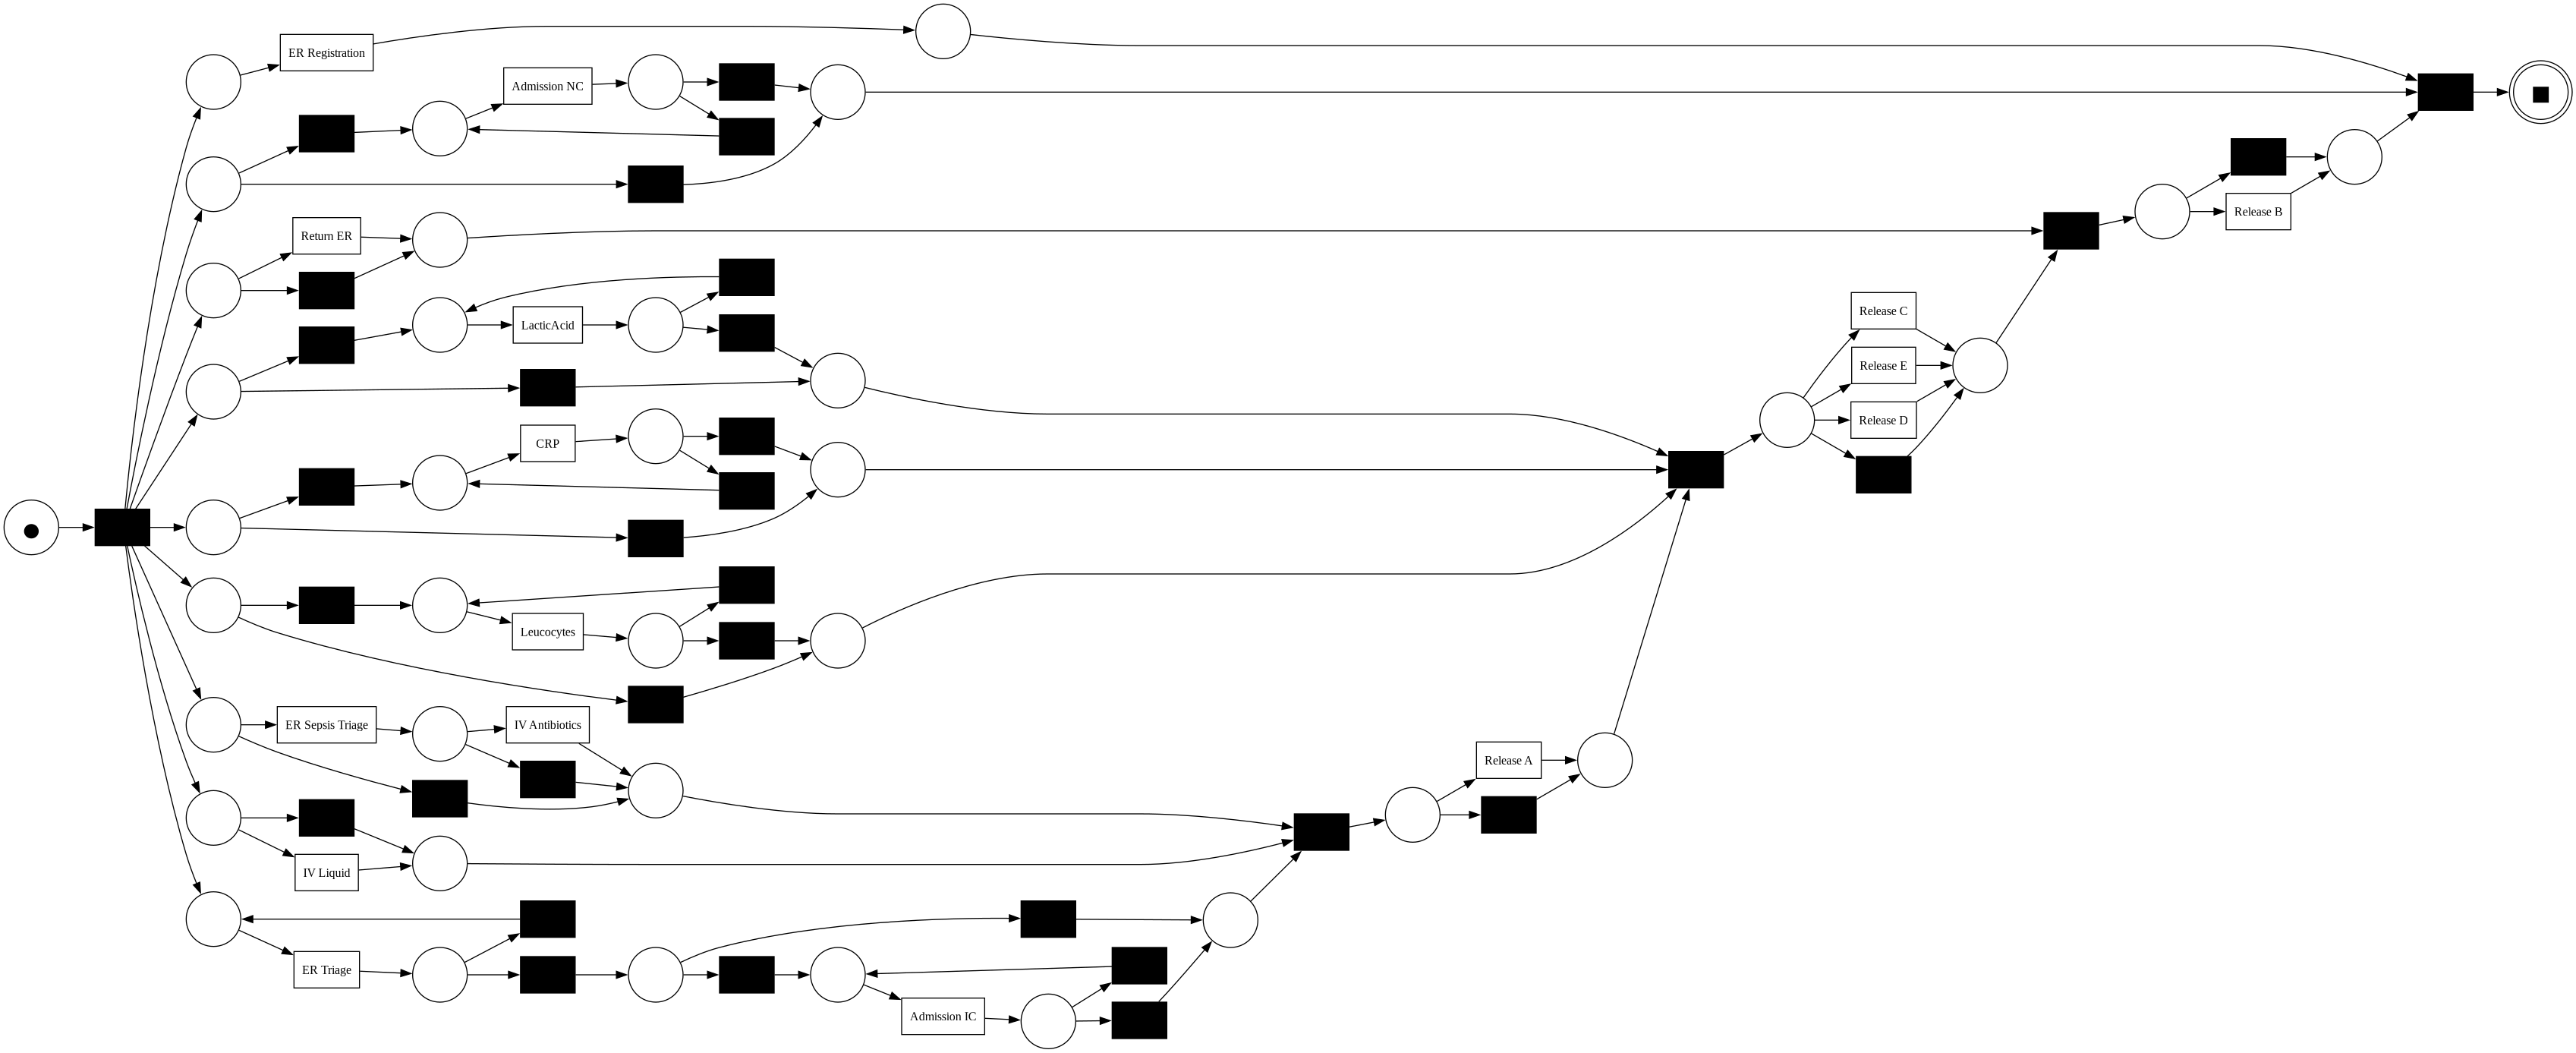

In [12]:
# Calculate and store markings:
import event_log_loader.petri_net_replay_markings
importlib.reload(event_log_loader.petri_net_replay_markings)
from event_log_loader.petri_net_replay_markings import InductiveMiner, PNReplayMarkings

# initialize the process 
miner = InductiveMiner(path_to_csv_log=event_log_location, case_id_col="case:concept:name", activity_col="concept:name", timestamp_col="time:timestamp", resource_col="org:resource")
net, im, fm = miner.discover_petri_net(visulaize=True, store_loc_file_path='../../../../encoded_data_conformal/Sepsis/prefix_for_replay/petri_net/sepsis.png')

In [13]:
# train set markings
replayer_train = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=train_pref_df, event_label="concept:name")

markings_train = replayer_train.get_markings_token_replay()

print("Amount markings: ", len(markings_train))
markings_counter_train = Counter(tuple(mark) for mark in markings_train)
markings_summary_train = ( pd.DataFrame([(list(mark), count) for mark, count in markings_counter_train.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_train

Amount markings:  10284


,marking,count
0,"[p_5, p_25, p_38, p_20, p_30, p_15, p_50, p_44...",666
1,"[p_5, p_25, p_38, p_20, p_30, p_15, p_50, p_11...",618
2,"[p_5, p_25, p_20, p_30, p_15, p_50, p_11, p_45...",546
3,"[p_15, p_11, p_45, p_33, p_51, p_39, p_8, p_23...",273
4,"[p_15, p_11, p_45, p_33, p_51, p_39, p_8, p_28...",267
...,...,...
1136,"[p_5, p_15, p_11, p_28, p_23, p_33, p_51, p_39...",1
1137,"[p_5, p_25, p_20, p_15, p_11, p_45, p_39, p_51...",1
1138,"[p_5, p_20, p_15, p_11, p_45, p_39, p_51, p_33...",1
1139,"[p_5, p_15, p_11, p_45, p_39, p_51, p_33, p_28...",1


In [14]:
# train set markings
replayer_val = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=val_pref_df, event_label="concept:name")

markings_val = replayer_val.get_markings_token_replay()

print("Amount markings: ", len(markings_val))
markings_counter_val = Counter(tuple(mark) for mark in markings_val)
markings_summary_val = (pd.DataFrame([(list(mark), count) for mark, count in markings_counter_val.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_val

Amount markings:  2752


,marking,count
0,"[p_5, p_25, p_38, p_20, p_30, p_15, p_50, p_44...",176
1,"[p_5, p_25, p_38, p_20, p_30, p_15, p_50, p_11...",166
2,"[p_5, p_25, p_20, p_30, p_15, p_50, p_11, p_45...",141
3,"[p_15, p_11, p_45, p_33, p_51, p_39, p_8, p_23...",67
4,"[p_15, p_11, p_45, p_33, p_51, p_39, p_8, p_28...",64
...,...,...
604,"[p_5, p_38, p_15, p_50, p_11, p_45, p_33, p_28...",1
605,"[p_5, p_38, p_15, p_11, p_45, p_33, p_28, p_23...",1
606,"[p_5, p_15, p_11, p_45, p_33, p_28, p_23, p_51...",1
607,"[p_15, p_11, p_45, p_23, p_51, p_39, p_33, p_8...",1


In [15]:
# train set markings
replayer_test = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=test_pref_df, event_label="concept:name")

markings_test = replayer_test.get_markings_token_replay()

print("Amount markings: ", len(markings_test))
markings_counter_test = Counter(tuple(mark) for mark in markings_test)
markings_summary_test = ( pd.DataFrame([(list(mark), count) for mark, count in markings_counter_test.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_test

Amount markings:  2154


,marking,count
0,"[p_5, p_25, p_38, p_20, p_30, p_15, p_50, p_44...",152
1,"[p_5, p_25, p_38, p_20, p_30, p_15, p_50, p_11...",138
2,"[p_5, p_25, p_20, p_30, p_15, p_50, p_11, p_45...",120
3,"[p_15, p_11, p_45, p_33, p_51, p_39, p_8, p_23...",74
4,"[p_15, p_11, p_45, p_33, p_51, p_39, p_8, p_28...",59
...,...,...
480,"[p_15, p_11, p_51, p_39, p_45, p_33, p_23, p_2...",1
481,"[p_15, p_11, p_51, p_39, p_45, p_33, p_28, p_8...",1
482,"[p_15, p_11, p_51, p_39, p_45, p_33, p_8, p_23...",1
483,"[p_5, p_15, p_11, p_45, p_40, p_23, p_28, p_51...",1


## Dtore datasets and credentials for Deep-NN

In [16]:
# object to create the tensors for the dnn models and further credentials
el_loader = EventLogLoader(event_log_location=event_log_location, event_log_properties=event_log_properties, prefix_df=pref_adopt_dataframe)

In [17]:
# 
test_set = el_loader.get_encoded_dataframe(type='test')
test_set

,InfectionSuspected,org:group,DiagnosticBlood,DisfuncOrg,SIRSCritTachypnea,Hypotensie,SIRSCritHeartRate,Infusion,DiagnosticArtAstrup,concept:name,...,DiagnosticUrinarySediment,DiagnosticECG,case:concept:name,Leucocytes,CRP,LacticAcid,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day
0,False,A,True,False,False,False,True,True,False,ER Registration,...,False,True,AAA,NaN,NaN,NaN,0.0,NaN,2.0,11781.0
1,NaN,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ER Triage,...,NaN,NaN,AAA,NaN,NaN,NaN,148.0,148.0,2.0,11929.0
2,NaN,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ER Sepsis Triage,...,NaN,NaN,AAA,NaN,NaN,NaN,168.0,20.0,2.0,11949.0
3,NaN,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IV Liquid,...,NaN,NaN,AAA,NaN,NaN,NaN,197.0,29.0,2.0,11978.0
4,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Leucocytes,...,NaN,NaN,AAA,20.799999,NaN,NaN,1599.0,1402.0,2.0,13380.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2934,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,...,EOS,EOS,ZZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2935,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,...,EOS,EOS,ZZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2936,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,...,EOS,EOS,ZZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2937,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,...,EOS,EOS,ZZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# train tensor dataset
train_set = el_loader.get_dataset('train')

# add markings to the train dataset credentials:
train_set.set_prefix_markings(markings=markings_train)

# save dataset 
torch.save(train_set, '../../../../encoded_data_conformal/Sepsis/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_train.pkl')

categorical tensors:   0%|          | 0/3 [00:00<?, ?it/s]

concept:name:   0%|          | 0/707 [00:00<?, ?it/s]

org:group:   0%|          | 0/707 [00:00<?, ?it/s]

lifecycle:transition:   0%|          | 0/707 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/7 [00:00<?, ?it/s]

...

seconds_in_day:   0%|          | 0/707 [00:00<?, ?it/s]

Leucocytes:   0%|          | 0/707 [00:00<?, ?it/s]

CRP:   0%|          | 0/707 [00:00<?, ?it/s]

LacticAcid:   0%|          | 0/707 [00:00<?, ?it/s]

static categorical:   0%|          | 0/10284 [00:00<?, ?it/s]

In [19]:
# Test get sizes and others
print("Min suffix size: ", train_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", train_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", train_set.all_static_categories)

print("Dynamic categorical tensor: ", train_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", train_set.continuous_tensors[0].size())

print("Static categorical tensor: ", train_set.static_categorical_tensor.size())
print("Static continuous tensor: ", train_set.static_continuous_tensor.size())

print("Zero padding tensor: ", train_set.zero_padding.size())
print("EOS padding tensor: ",train_set.eos_padding.size())

print("Prefix petri net replay tensor: ", len(train_set.prefixes_petri_net_marking))
print(train_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 18, {'Admission IC': 1, 'Admission NC': 2, 'CRP': 3, 'EOS': 4, 'ER Registration': 5, 'ER Sepsis Triage': 6, 'ER Triage': 7, 'IV Antibiotics': 8, 'IV Liquid': 9, 'LacticAcid': 10, 'Leucocytes': 11, 'Release A': 12, 'Release B': 13, 'Release C': 14, 'Release D': 15, 'Release E': 16, 'Return ER': 17}), ('org:group', 27, {'?': 1, 'A': 2, 'B': 3, 'C': 4, 'D': 5, 'E': 6, 'EOS': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'J': 12, 'K': 13, 'L': 14, 'M': 15, 'N': 16, 'O': 17, 'P': 18, 'Q': 19, 'R': 20, 'S': 21, 'T': 22, 'U': 23, 'V': 24, 'W': 25, 'X': 26}), ('lifecycle:transition', 3, {'EOS': 1, 'complete': 2})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {}), ('Leucocytes', 1, {}), ('CRP', 1, {}), ('LacticAcid', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('Age', 16, {20.0: 1

In [20]:
# train tensor dataset
val_set = el_loader.get_dataset('val')

# add markings to the train dataset credentials:
val_set.set_prefix_markings(markings=markings_val)

# save dataset 
torch.save(val_set, '../../../../encoded_data_conformal/Sepsis/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_val.pkl')

categorical tensors:   0%|          | 0/3 [00:00<?, ?it/s]

concept:name:   0%|          | 0/185 [00:00<?, ?it/s]

org:group:   0%|          | 0/185 [00:00<?, ?it/s]

lifecycle:transition:   0%|          | 0/185 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/7 [00:00<?, ?it/s]

...

seconds_in_day:   0%|          | 0/185 [00:00<?, ?it/s]

Leucocytes:   0%|          | 0/185 [00:00<?, ?it/s]

CRP:   0%|          | 0/185 [00:00<?, ?it/s]

LacticAcid:   0%|          | 0/185 [00:00<?, ?it/s]

static categorical:   0%|          | 0/2752 [00:00<?, ?it/s]

In [21]:
# Test get sizes and others
print("Min suffix size: ", val_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", val_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", val_set.all_static_categories)

print("Dynamic categorical tensor: ", val_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", val_set.continuous_tensors[0].size())

print("Static categorical tensor: ", val_set.static_categorical_tensor.size())
print("Static continuous tensor: ", val_set.static_continuous_tensor.size())

print("Zero padding tensor: ", val_set.zero_padding.size())
print("EOS padding tensor: ",val_set.eos_padding.size())

print("Prefix petri net replay tensor: ", len(val_set.prefixes_petri_net_marking))
print(val_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 18, {'Admission IC': 1, 'Admission NC': 2, 'CRP': 3, 'EOS': 4, 'ER Registration': 5, 'ER Sepsis Triage': 6, 'ER Triage': 7, 'IV Antibiotics': 8, 'IV Liquid': 9, 'LacticAcid': 10, 'Leucocytes': 11, 'Release A': 12, 'Release B': 13, 'Release C': 14, 'Release D': 15, 'Release E': 16, 'Return ER': 17}), ('org:group', 27, {'?': 1, 'A': 2, 'B': 3, 'C': 4, 'D': 5, 'E': 6, 'EOS': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'J': 12, 'K': 13, 'L': 14, 'M': 15, 'N': 16, 'O': 17, 'P': 18, 'Q': 19, 'R': 20, 'S': 21, 'T': 22, 'U': 23, 'V': 24, 'W': 25, 'X': 26}), ('lifecycle:transition', 3, {'EOS': 1, 'complete': 2})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {}), ('Leucocytes', 1, {}), ('CRP', 1, {}), ('LacticAcid', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('Age', 16, {20.0: 1

In [22]:
# train tensor dataset
test_set = el_loader.get_dataset('test')

# add markings to the train dataset credentials:
test_set.set_prefix_markings(markings=markings_test)

# save dataset 
torch.save(test_set, '../../../../encoded_data_conformal/Sepsis/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_test.pkl')

categorical tensors:   0%|          | 0/3 [00:00<?, ?it/s]

concept:name:   0%|          | 0/157 [00:00<?, ?it/s]

org:group:   0%|          | 0/157 [00:00<?, ?it/s]

lifecycle:transition:   0%|          | 0/157 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/7 [00:00<?, ?it/s]

...

seconds_in_day:   0%|          | 0/157 [00:00<?, ?it/s]

Leucocytes:   0%|          | 0/157 [00:00<?, ?it/s]

CRP:   0%|          | 0/157 [00:00<?, ?it/s]

LacticAcid:   0%|          | 0/157 [00:00<?, ?it/s]

static categorical:   0%|          | 0/2154 [00:00<?, ?it/s]

In [23]:
# Test get sizes and others
print("Min suffix size: ", test_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", test_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", test_set.all_static_categories)

print("Dynamic categorical tensor: ", test_set.categorical_tensors[0].size())
# print("Dynamic categorical tensor examples: ", test_set.categorical_tensors[0][10:55])
print("Dynamic continuous tensor: ", test_set.continuous_tensors[0].size())

print("Static categorical tensor: ", test_set.static_categorical_tensor.size())
print("Static continuous tensor: ", test_set.static_continuous_tensor.size())

print("Zero padding tensor: ", test_set.zero_padding.size())
print("EOS padding tensor: ",test_set.eos_padding.size())
# print("Zero padds: ", test_set.zero_padding[35:41])
# print("EOS padds: ", test_set.eos_padding[35:41])

print("Prefix petri net replay tensor: ", len(test_set.prefixes_petri_net_marking))
print(test_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 18, {'Admission IC': 1, 'Admission NC': 2, 'CRP': 3, 'EOS': 4, 'ER Registration': 5, 'ER Sepsis Triage': 6, 'ER Triage': 7, 'IV Antibiotics': 8, 'IV Liquid': 9, 'LacticAcid': 10, 'Leucocytes': 11, 'Release A': 12, 'Release B': 13, 'Release C': 14, 'Release D': 15, 'Release E': 16, 'Return ER': 17}), ('org:group', 27, {'?': 1, 'A': 2, 'B': 3, 'C': 4, 'D': 5, 'E': 6, 'EOS': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'J': 12, 'K': 13, 'L': 14, 'M': 15, 'N': 16, 'O': 17, 'P': 18, 'Q': 19, 'R': 20, 'S': 21, 'T': 22, 'U': 23, 'V': 24, 'W': 25, 'X': 26}), ('lifecycle:transition', 3, {'EOS': 1, 'complete': 2})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {}), ('Leucocytes', 1, {}), ('CRP', 1, {}), ('LacticAcid', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('Age', 16, {20.0: 1